# 문제 2 인플루엔자 공통 시나리오 F1·F2 (v3): 검출률 입력 기반 49주 전망

**이 노트북이 하는 일**
1. `인플루엔자 2차 학습 데이터_아형 검출률 추가.xlsx`(ILI·ARI·검출률 모두 2026-39까지, 결측 없음)를 읽습니다. 결측값을 채우는 처리는 하지 않으며, 결측이 있으면 오류로 멈춥니다.
2. 기점 **2026-39**에서 2026-40 ~ 2027-35(49주)의 ILI와 인플루엔자 입원(ARI, `flu_hosp`)을 전망합니다.
3. 모형은 v2의 **수준 모형(검출률 → 로그 ILI) + AR(1) 오차**입니다. 미래 검출률(전체·A(H1N1)pdm09·A(H3N2)·B)을 시나리오로 만들어 입력합니다.
4. F1·F2와 대표 전망(REP, 두 시나리오의 경로를 그대로 합친 1/2 : 1/2 균등 혼합)을 7분위수로 저장하고, 시나리오 설정 내역을 `scenario_spec.json`에 기록합니다.
5. 롤링 백테스트로 모형과 구간 폭을 고르고, 부록 B 기준모형 대비 상대 WIS를 막대그래프로 보여 줍니다.

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Image

plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.edgecolor': '#555555', 'axes.labelcolor': '#222222', 'xtick.color': '#444444', 'ytick.color': '#444444',
                     'axes.grid': True, 'grid.color': '#E6E6E6', 'grid.linewidth': 0.8, 'figure.dpi': 110, 'savefig.dpi': 220})

SEED = 2026
QUANTILES = np.array([0.025, 0.10, 0.25, 0.50, 0.75, 0.90, 0.975])
QCOLS = ['q0.025', 'q0.10', 'q0.25', 'q0.50', 'q0.75', 'q0.90', 'q0.975']
FLU_COLS = ['전체 검출률(%)', 'A(H1N1)pdm09', 'A(H3N2)', 'B']
DATA_PATH = '인플루엔자 2차 학습 데이터_아형 검출률 추가.xlsx'
RESULT_DIR = Path('results')
RESULT_DIR.mkdir(exist_ok=True)

ORIGIN = 202639          # 기점(학습 마지막 주)
N_STEPS = 49             # 2026-40 ~ 2027-35
N_PATHS = 1000
COVID = (202010, 202225)  # 코로나19 유행기(학습·평가에서 제외)
H3B_LIMIT = 5.0          # F1: A(H3N2)+B 검출률 합 상한(%)
F2_ONSET = 202648        # F2: A(H3N2) 상승 시작 주차
F2_ONSET_JITTER = 2      # 상승 시작 ±주 (균등)
EPI_THRESHOLD = 12.9     # 2026-27절기 유행기준(의사환자분율, 외래 1,000명당)
CANDIDATE_SETS = {'Ridge': ['Ridge'], 'ET': ['ET'], 'HGB': ['HGB'], 'Ridge+ET': ['Ridge', 'ET'], 'Ridge+ET+HGB': ['Ridge', 'ET', 'HGB']}
SCALES = [1.0, 1.25, 1.5, 2.0]
BACKTEST_STEP = 12
COL = {'H1': '#D55E00', 'H3': '#0072B2', 'B': '#009E73', 'total': '#222222', 'F1': '#1F4E9C', 'F2': '#C2185B', 'REP': '#6A4C93', 'obs': '#222222'}


# ---------- 자료 ----------
def load_data(path):
    """2차 학습 데이터(아형 검출률 추가본) 읽기. 결측값을 채우지 않고, 필요한 열에 결측이 있으면 오류로 멈춘다."""
    df = pd.read_excel(path).sort_values('년주').reset_index(drop=True)
    assert df['년주'].is_unique
    need = ['ILI', 'ARI'] + FLU_COLS
    assert df[need].notna().all().all(), f'결측 있음: {df[need].isna().sum().to_dict()}'
    return df


def next_weeks(origin, count=5):
    """기점 다음 주부터 count개 주차 라벨. 2026년은 53주."""
    weeks_in_year = {2016: 53, 2017: 52, 2018: 52, 2019: 52, 2020: 52, 2021: 52, 2022: 53, 2023: 52, 2024: 52, 2025: 52, 2026: 53, 2027: 52}
    year, week = divmod(origin, 100)
    labels = []
    for _ in range(count):
        week += 1
        if week > weeks_in_year[year]:
            year, week = year + 1, 1
        labels.append(f'{year}-{week:02d}')
    return labels


def wis(q, actual):
    """부록 B의 WIS. q: (n, 7) 분위수, actual: (n,)."""
    score = 0.5 * np.abs(actual - q[:, 3])
    for alpha, lo, hi in [(0.05, 0, 6), (0.20, 1, 5), (0.50, 2, 4)]:
        l, u = q[:, lo], q[:, hi]
        score += alpha / 2 * (u - l + 2 / alpha * np.maximum(l - actual, 0) + 2 / alpha * np.maximum(actual - u, 0))
    return score / 3.5


def season_of(yearweek):
    year, week = divmod(int(yearweek), 100)
    return year if week >= 36 else year - 1


def smooth3(a):
    p = np.pad(np.asarray(a, float), 1, mode='edge')
    return (p[:-2] + p[1:-1] + p[2:]) / 3


data = load_data(DATA_PATH)
train = data.loc[data['년주'] <= ORIGIN].copy().reset_index(drop=True)
assert train['년주'].iloc[-1] == ORIGIN
print('학습 마지막 5주:')
display(train[['년주', 'ILI', 'ARI'] + FLU_COLS].tail(5))

학습 마지막 5주:


,년주,ILI,ARI,전체 검출률(%),A(H1N1)pdm09,A(H3N2),B
556,202635,13.3,166,12.3,12.3,0.0,0.0
557,202636,21.4,304,16.3,15.9,0.2,0.2
558,202637,27.1,428,24.6,24.2,0.2,0.2
559,202638,30.9,438,20.7,20.7,0.0,0.0
560,202639,32.4,401,26.4,26.1,0.3,0.0


## 1. 수준 모형 + AR 오차 (v2와 동일한 구조)
그 주의 검출률(현재·1주 전·3주 평균·로그)과 계절 주기로 로그 ILI(또는 로그 입원 ARI)를 직접 설명하고, 남는 오차는 AR(1)로 이어 갑니다. 오차의 표본은 절기 단위 leave-one-season-out 예측에서 구합니다.

In [2]:
def make_member(name):
    if name == 'Ridge':
        return make_pipeline(StandardScaler(), Ridge(alpha=3.0))
    if name == 'ET':
        return ExtraTreesRegressor(n_estimators=200, min_samples_leaf=3, max_features=0.7, random_state=SEED, n_jobs=1)
    return HistGradientBoostingRegressor(max_iter=150, max_leaf_nodes=6, min_samples_leaf=15, learning_rate=0.05, l2_regularization=5, random_state=SEED)


def level_design(Z, wk):
    """Z: (..., T, 4) 검출률(%) 전체·H1·H3·B, wk: (T,) 주차 → (..., T-2, 특성)."""
    cur, lag = Z[..., 2:, :], Z[..., 1:-1, :]
    m3 = (Z[..., 2:, :] + Z[..., 1:-1, :] + Z[..., :-2, :]) / 3
    ang = 2 * np.pi * np.asarray(wk, float)[2:] / 52.18
    shape = cur.shape[:-1] + (1,)
    return np.concatenate([cur, lag, np.log1p(cur), m3, np.broadcast_to(np.sin(ang)[:, None], shape), np.broadcast_to(np.cos(ang)[:, None], shape)], axis=-1)


def training_table(df, target):
    X = level_design(df[FLU_COLS].to_numpy(float), df['주차'].to_numpy(float))
    y = np.log1p(df[target].to_numpy(float))[2:]
    yw = df['년주'].to_numpy(int)[2:]
    ok = ~((yw >= COVID[0]) & (yw <= COVID[1]))
    return X, y, ok, np.array([season_of(v) for v in yw])


def fit_level(X, y, members):
    return {m: make_member(m).fit(X, y) for m in members}


def level_predict(models, X):
    flat = X.reshape(-1, X.shape[-1])
    return {m: mod.predict(flat).reshape(X.shape[:-1]) for m, mod in models.items()}


def loso_predictions(X, y, ok, season, members):
    pred = {m: np.full(len(y), np.nan) for m in members}
    for s in np.unique(season[ok]):
        test, tr = (season == s) & ok, ok & (season != s)
        if tr.sum() < 50:
            continue
        mods = fit_level(X[tr], y[tr], members)
        for m in members:
            pred[m][test] = mods[m].predict(X[test])
    return pred


def ar_fit(e):
    a, b = e[:-1], e[1:]
    good = np.isfinite(a) & np.isfinite(b)
    phi = float(np.clip(np.sum(a[good] * b[good]) / np.sum(a[good] ** 2), 0.0, 0.97))
    eps = b[good] - phi * a[good]
    return phi, eps - np.median(eps)


def fit_forecaster(df, target='ILI'):
    members = ['Ridge', 'ET', 'HGB']
    X, y, ok, season = training_table(df, target)
    return {'models': fit_level(X[ok], y[ok], members), 'loso': loso_predictions(X, y, ok, season, members), 'y': y, 'ok': ok}


def candidate_state(fc, cand):
    pred = np.mean([fc['loso'][m] for m in CANDIDATE_SETS[cand]], axis=0)
    e = fc['y'] - pred
    e[~fc['ok']] = np.nan
    phi, eps = ar_fit(e)
    return phi, eps, (float(e[-1]) if np.isfinite(e[-1]) else 0.0)


def simulate(fc, cand, Zext, wk_ext, phi, eps, e0, scale, rng, n_paths=None):
    """Zext: (N, 2+T, 4) 과거 2주 + 미래 검출률. 반환 (N, T) 경로(원 척도)."""
    f = np.mean([level_predict(fc['models'], level_design(Zext, wk_ext))[m] for m in CANDIDATE_SETS[cand]], axis=0)
    N, T = f.shape
    if n_paths is not None and N == 1:
        f, N = np.repeat(f, n_paths, axis=0), n_paths
    e = np.full(N, e0)
    out = np.empty((N, T))
    for k in range(T):
        e = phi * e + scale * rng.choice(eps, size=N)
        out[:, k] = np.expm1(f[:, k] + e)
    return np.maximum(out, 0)

## 2. 롤링 백테스트와 기준모형(부록 B) 대비 상대 WIS
과거 여러 기점에서 최대 49주 앞을 **실제 검출률을 조건으로** 예측하고, 후보 모형과 구간 배율을 WIS로 고릅니다. 기준모형(부록 B): 중앙값 = 기점 관측값, 분위수 = 기점 관측값 + 과거 h주 변화량의 경험 분위수(0 중심 대칭화), 0 미만은 0. 기후평균(같은 주차 ±1주의 과거 분위수)도 참고로 봅니다.

backtest 1/23 (origin 201834)


backtest 2/23 (origin 201846)


backtest 3/23 (origin 201906)


backtest 4/23 (origin 201918)


backtest 5/23 (origin 201930)


...

,model,scale,WIS,MAE,cov95,cov50,relative_WIS_vs_baseline,relative_WIS_vs_climatology
0,Ridge+ET,1.25,2.734,5.041,0.929,0.516,0.289,0.489
1,Ridge+ET,1.00,2.755,5.018,0.891,0.418,0.291,0.493
2,Ridge+ET+HGB,1.25,2.781,5.233,0.925,0.478,0.294,0.497
3,ET,1.25,2.790,5.199,0.930,0.520,0.294,0.499
4,ET,1.00,2.806,5.100,0.884,0.422,0.296,0.502
5,Ridge,1.00,2.809,5.210,0.922,0.482,0.296,0.502
6,Ridge,1.25,2.815,5.395,0.977,0.552,0.297,0.503
7,Ridge+ET,1.50,2.828,5.197,0.965,0.588,0.298,0.506
8,Ridge+ET+HGB,1.50,2.832,5.333,0.961,0.552,0.299,0.506
9,Ridge+ET+HGB,1.00,2.835,5.160,0.873,0.402,0.299,0.507


선택: Ridge+ET (AR 혁신 배율 1.25) | 기준모형 대비 상대 WIS 0.289


전체(1~49주 앞) 상대 WIS = 0.289


,band,모형 WIS,기준모형 WIS,상대 WIS,기후평균 상대 WIS
0,1-5주,2.154,5.052,0.426,0.869
1,6-15주,3.038,10.320,0.294,0.529
2,16-30주,2.846,10.612,0.268,0.550
3,31-49주,2.624,9.310,0.282,0.627


,origin,모형 WIS,기준모형 WIS,상대 WIS,기후평균 상대 WIS
0,201834,2.562,7.072,0.362,0.579
1,201846,2.736,7.290,0.375,0.549
2,201906,1.895,6.270,0.302,0.581
3,201918,1.526,8.520,0.179,0.250
4,201930,1.713,6.266,0.273,0.415
5,201942,2.615,9.428,0.277,0.425
6,202242,6.727,7.280,0.924,0.859
7,202301,4.390,18.056,0.243,0.585
8,202313,3.976,6.808,0.584,1.569
9,202325,3.046,6.171,0.494,1.453


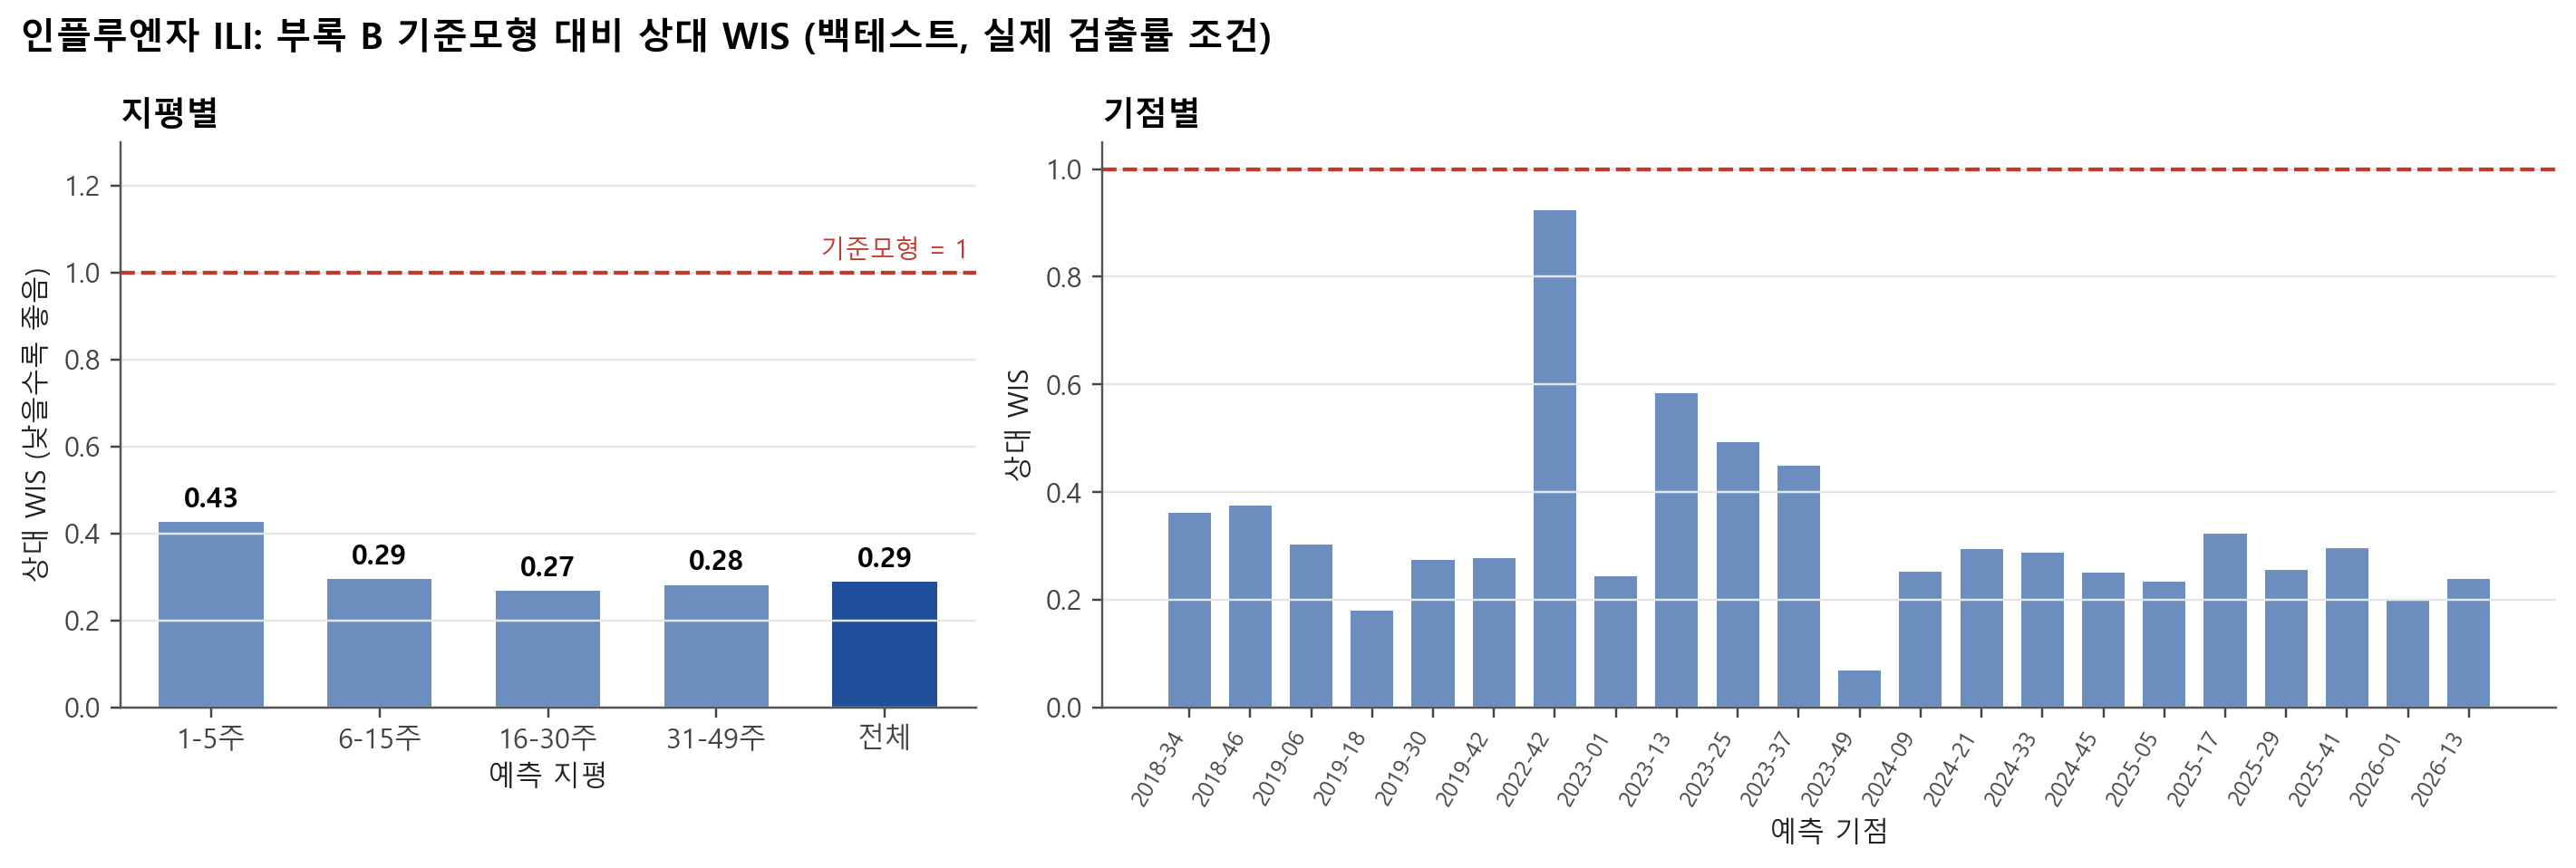

In [3]:
def baseline_quantiles(hist, T):
    yy = hist['ILI'].to_numpy(float)
    out = []
    for h in range(1, T + 1):
        change = yy[h:] - yy[:-h]
        change = np.r_[change, -change]
        out.append(np.maximum(0, yy[-1] + np.quantile(change, QUANTILES)))
    return np.asarray(out)


def climatology_quantiles(df, target_weeks):
    wk = df['주차'].to_numpy(int)
    ok = ~df['년주'].between(*COVID).to_numpy()
    ili = df['ILI'].to_numpy(float)
    return np.asarray([np.quantile(ili[ok & (np.minimum(np.abs(wk - w), 52 - np.abs(wk - w)) <= 1)], QUANTILES) for w in target_weeks])


def backtest(df, step=BACKTEST_STEP, horizon=N_STEPS):
    rng = np.random.default_rng(SEED)
    first = int(np.flatnonzero(df['년주'].to_numpy() == 201834)[0])
    origins = [i for i in range(first, len(df) - 20, step) if not COVID[0] <= df['년주'].iloc[i] <= COVID[1] + 12]
    rows = []

    def add(origin, name, scale, t_idx, q, a):
        rows.append({'origin': origin, 'model': name, 'scale': scale, 'h': int(t_idx + 1), 'WIS': float(wis(q[t_idx:t_idx + 1], a[t_idx:t_idx + 1])[0]),
                     'abs_err': abs(q[t_idx, 3] - a[t_idx]), 'cov95': float(q[t_idx, 0] <= a[t_idx] <= q[t_idx, 6]), 'cov50': float(q[t_idx, 2] <= a[t_idx] <= q[t_idx, 4])})

    for n_o, i0 in enumerate(origins):
        hist = df.iloc[:i0 + 1]
        T = min(horizon, len(df) - 1 - i0)
        fut = df.iloc[i0 + 1:i0 + 1 + T]
        keep = ~fut['년주'].between(*COVID).to_numpy()
        if keep.sum() < 10:
            continue
        actual = fut['ILI'].to_numpy(float)
        origin = int(df['년주'].iloc[i0])
        Zext = df[FLU_COLS].to_numpy(float)[i0 - 1:i0 + 1 + T][None]
        wk_ext = df['주차'].to_numpy(float)[i0 - 1:i0 + 1 + T]
        fc = fit_forecaster(hist)
        for name, q in [('Climatology', climatology_quantiles(hist, fut['주차'].to_numpy(int))), ('Baseline', baseline_quantiles(hist, T))]:
            for t_idx in np.flatnonzero(keep):
                add(origin, name, np.nan, t_idx, q, actual)
        for cand in CANDIDATE_SETS:
            phi, eps, e0 = candidate_state(fc, cand)
            for scale in SCALES:
                q = np.quantile(simulate(fc, cand, Zext, wk_ext, phi, eps, e0, scale, rng, n_paths=300), QUANTILES, axis=0).T
                for t_idx in np.flatnonzero(keep):
                    add(origin, cand, scale, t_idx, q, actual)
        print(f'backtest {n_o + 1}/{len(origins)} (origin {origin})', flush=True)
    return pd.DataFrame(rows)


bt = backtest(train)
bt.to_csv(RESULT_DIR / 'backtest_by_step.csv', index=False)
bt['band'] = pd.cut(bt['h'], [0, 5, 15, 30, 49], labels=['1-5주', '6-15주', '16-30주', '31-49주'])
summary = bt.groupby(['model', 'scale'], dropna=False).agg(WIS=('WIS', 'mean'), MAE=('abs_err', 'mean'), cov95=('cov95', 'mean'), cov50=('cov50', 'mean')).reset_index()
base_wis = float(summary.loc[summary['model'] == 'Baseline', 'WIS'].iloc[0])
clim_wis = float(summary.loc[summary['model'] == 'Climatology', 'WIS'].iloc[0])
summary['relative_WIS_vs_baseline'] = summary['WIS'] / base_wis
summary['relative_WIS_vs_climatology'] = summary['WIS'] / clim_wis
summary = summary.sort_values('WIS').reset_index(drop=True)
summary.to_csv(RESULT_DIR / 'backtest_summary.csv', index=False)
display(summary.round(3).head(10))
best = summary.loc[~summary['model'].isin(['Climatology', 'Baseline'])].iloc[0]
BEST_MODEL, BEST_SCALE = str(best['model']), float(best['scale'])
print(f'선택: {BEST_MODEL} (AR 혁신 배율 {BEST_SCALE}) | 기준모형 대비 상대 WIS {best["relative_WIS_vs_baseline"]:.3f}')

# 상대 WIS 표
sel = bt[(bt['model'] == BEST_MODEL) & (bt['scale'] == BEST_SCALE)]
base_df, clim_df = bt[bt['model'] == 'Baseline'], bt[bt['model'] == 'Climatology']


def rel_table(col):
    a, b, c = (g.groupby(col, observed=True)['WIS'].mean() for g in (sel, base_df, clim_df))
    return pd.DataFrame({'모형 WIS': a, '기준모형 WIS': b, '상대 WIS': a / b, '기후평균 상대 WIS': c / b}).reset_index()


rel_band, rel_origin = rel_table('band'), rel_table('origin')
rel_total = float(sel['WIS'].mean() / base_df['WIS'].mean())
rel_band.to_csv(RESULT_DIR / 'relative_WIS_by_horizon.csv', index=False)
rel_origin.to_csv(RESULT_DIR / 'relative_WIS_by_origin.csv', index=False)
print(f'전체(1~49주 앞) 상대 WIS = {rel_total:.3f}')
display(rel_band.round(3))
display(rel_origin.round(3))


def relative_wis_figure(rel_band, rel_origin, rel_total, path, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={'width_ratios': [1, 1.7]})
    ax = axes[0]
    labels = list(rel_band.iloc[:, 0].astype(str)) + ['전체']
    vals = list(rel_band['상대 WIS']) + [rel_total]
    bars = ax.bar(labels, vals, color=['#6C8EBF'] * len(rel_band) + ['#1F4E9C'], width=0.62)
    ax.bar_label(bars, labels=[f'{v:.2f}' for v in vals], padding=3, fontsize=10, fontweight='bold')
    ax.axhline(1.0, color='#C0392B', linestyle='--', linewidth=1.4)
    ax.text(len(vals) - 0.5, 1.02, '기준모형 = 1', color='#C0392B', ha='right', va='bottom', fontsize=9)
    ax.set_ylim(0, max(vals + [1.0]) * 1.3)
    ax.set_xlabel('예측 지평'); ax.set_ylabel('상대 WIS (낮을수록 좋음)')
    ax.set_title('지평별', loc='left', fontweight='bold')
    ax.grid(axis='x', visible=False)
    ax = axes[1]
    ob = [f'{int(o) // 100}-{int(o) % 100:02d}' for o in rel_origin.iloc[:, 0]]
    ax.bar(ob, rel_origin['상대 WIS'], color='#6C8EBF', width=0.7)
    ax.axhline(1.0, color='#C0392B', linestyle='--', linewidth=1.4)
    ax.set_xticks(range(len(ob)), ob, rotation=60, ha='right', fontsize=8)
    ax.set_xlabel('예측 기점'); ax.set_ylabel('상대 WIS')
    ax.set_title('기점별', loc='left', fontweight='bold')
    ax.grid(axis='x', visible=False)
    fig.suptitle(title, x=0.01, ha='left', fontsize=13, fontweight='bold')
    fig.tight_layout()
    fig.savefig(path, bbox_inches='tight')
    plt.close(fig)


relative_wis_figure(rel_band, rel_origin, rel_total, RESULT_DIR / 'relative_WIS_vs_baseline.png', '인플루엔자 ILI: 부록 B 기준모형 대비 상대 WIS (백테스트, 실제 검출률 조건)')
display(Image(filename=str(RESULT_DIR / 'relative_WIS_vs_baseline.png')))

## 3. 시나리오 검출률 입력
전체 검출률 = A(H1N1)pdm09 + A(H3N2) + B 입니다. 세부 설정은 같은 폴더의 `시나리오설정_인플루엔자.docx`에 정리합니다.

| 구성 | F1 | F2 |
|---|---|---|
| A(H1N1)pdm09 | 과거 H1 우세 파동 곡선(현재 수준에 정렬)을 경로마다 무작위로 선택 | F1과 동일 |
| A(H3N2)·B | 예측 각 주의 **1년 전 → 2년 전 같은 주차** 합이 5% 미만이면 그 검출률을 그대로 사용, 둘 다 5% 이상이면 배경 수준으로 대체(`h3b_prior_years`) | B는 F1과 동일, **A(H3N2)** 는 2026-48 전후(±2주) 상승 시작, 2025-26절기 H3N2 곡선의 증감 비율을 따름 |

In [4]:
def background_h3b(df):
    wk = df['주차'].to_numpy(int)
    ok = (wk >= 20) & (wk <= 35) & ~df['년주'].between(*COVID).to_numpy()
    return float(np.median((df['A(H3N2)'] + df['B']).to_numpy(float)[ok]))


def h3b_prior_years(df, labels, limit=H3B_LIMIT):
    """F1용 A(H3N2)·B 미래 검출률(%). 예측 각 주의 '1년 전 → 2년 전' 같은 주차(해당 주차가 없으면 바로 앞 주차)를 차례로 보고,
    A(H3N2)+B 합이 limit(5%) 미만이면 그 주의 검출률을 그대로 쓴다. 두 해 모두 5% 이상이면(겨울 파동 주) 합을 과거 비유행기 배경 수준(20~35주 중앙값)으로
    낮추고 1년 전 주의 A(H3N2):B 구성비를 유지한다(상한 limit-0.1). 학습 마지막 시점 값은 쓰지 않는다."""
    avail = df.set_index('년주')[['A(H3N2)', 'B']]
    bg = min(background_h3b(df), limit - 0.1)
    h3, b, rows = [], [], []
    for lab in labels:
        y, w = map(int, lab.split('-'))
        pair = {}
        for back in (1, 2):
            ww = w
            while (y - back) * 100 + ww not in avail.index:
                ww -= 1
            src = (y - back) * 100 + ww
            pair[back] = (src, float(avail.loc[src, 'A(H3N2)']), float(avail.loc[src, 'B']))
        chosen = None
        for back in (1, 2):
            src, a, bb = pair[back]
            if a + bb < limit:
                chosen = (f'{back}년 전', src, a, bb)
                break
        if chosen is None:
            src, a, bb = pair[1]
            share = a / (a + bb) if a + bb > 0 else 0.5
            chosen = ('대체(배경 수준)', src, bg * share, bg * (1 - share))
        rows.append({'target_week': lab, 'source': chosen[0], 'source_week': chosen[1], 'A(H3N2)': chosen[2], 'B': chosen[3],
                     '1년전 H3N2+B': pair[1][1] + pair[1][2], '2년전 H3N2+B': pair[2][1] + pair[2][2]})
        h3.append(chosen[2]); b.append(chosen[3])
    return np.array(h3), np.array(b), pd.DataFrame(rows)


def h1_analogs(df, current):
    """과거 H1 우세 파동(절기 50주 이상, 누적 검출률 ≥200, 정점 ≥25%)의 곡선. 상승기에서 현재 수준에 가장 가까운 시점을 맞춰 현재 수준으로 정규화."""
    curves, detail = {}, []
    d = df.assign(s=df['년주'].map(season_of))
    full = smooth3(d['A(H1N1)pdm09'].to_numpy(float))
    for s, g in d.groupby('s'):
        h1 = g['A(H1N1)pdm09'].to_numpy(float)
        if len(g) < 50 or h1.sum() < 200 or h1.max() < 25:
            continue
        sm = smooth3(h1)
        cand = np.arange(0, int(np.argmax(sm)) + 1)
        cand = cand[sm[cand] > 0]
        o0 = cand[np.argmin(np.abs(np.log(sm[cand]) - np.log(current)))]
        start = int(np.flatnonzero(d['년주'].to_numpy() == g['년주'].iloc[o0])[0])
        seg = full[start:start + N_STEPS + 1]
        if len(seg) == N_STEPS + 1:
            curves[int(s)] = current * seg[1:] / seg[0]
            detail.append({'season': int(s), 'align_week': int(g['년주'].iloc[o0]), 'level_at_align(smoothed %)': float(seg[0]), 'season_peak(smoothed %)': float(sm.max()), 'scale_factor': float(current / seg[0])})
    return curves, detail


def h3_template(df, season=2025):
    """2025-26절기 A(H3N2) 검출률(3주 평활) 중 1% 이상이 되는 첫 주부터의 곡선."""
    g = df[df['년주'].map(season_of) == season]
    sm = smooth3(g['A(H3N2)'].to_numpy(float))
    o0 = int(np.flatnonzero(sm >= 1.0)[0])
    return sm[o0:], int(g['년주'].iloc[o0]), int(g['년주'].iloc[int(np.argmax(sm))])


def build_det_paths(df, scenario, rng, n_paths=N_PATHS):
    """미래 검출률 경로 (n_paths, N_STEPS, 4): 전체, H1, H3, B (%)."""
    h1_now = float(df['A(H1N1)pdm09'].iloc[-1])
    analogs, analog_detail = h1_analogs(df, h1_now)
    keys = sorted(analogs)
    labels = next_weeks(ORIGIN, N_STEPS)
    h3_hold, b_hold, h3b_table = h3b_prior_years(df, labels)
    onset_idx = labels.index(f'{F2_ONSET // 100}-{F2_ONSET % 100:02d}')
    tmpl, tmpl_start, tmpl_peak = h3_template(df)
    paths = np.zeros((n_paths, N_STEPS, 4))
    chosen, onsets = [], []
    for i in range(n_paths):
        k = keys[rng.integers(len(keys))]
        h3 = h3_hold.copy()
        if scenario == 'F2':
            on = onset_idx + int(rng.integers(-F2_ONSET_JITTER, F2_ONSET_JITTER + 1))
            wave = np.zeros(N_STEPS - on)
            m = min(len(wave), len(tmpl))
            wave[:m] = tmpl[:m]
            h3[on:] = np.maximum(h3[on:], wave)
            onsets.append(on - onset_idx)
        paths[i, :, 1], paths[i, :, 2], paths[i, :, 3] = analogs[k], h3, b_hold
        paths[i, :, 0] = paths[i, :, 1:].sum(axis=1)
        chosen.append(k)
    info = {'h3b_method': 'prior_year_same_week', 'h3b_limit_pct': H3B_LIMIT, 'h3b_background_pct': background_h3b(df),
            'h3b_source_counts': h3b_table['source'].value_counts().to_dict(),
            'h3b_fallback_weeks': h3b_table.loc[h3b_table['source'] == '대체(배경 수준)', 'target_week'].tolist(),
            'h3b_max_sum_pct': float((h3_hold + b_hold).max()),
            'h1_current_pct': h1_now, 'h1_analogs': analog_detail,
            'h3_template': {'source_season': '2025-26', 'start_week': tmpl_start, 'peak_week': tmpl_peak, 'peak_pct_smoothed': float(tmpl.max()), 'start_pct_smoothed': float(tmpl[0]), 'length_weeks': int(len(tmpl))},
            'f2_onset': F2_ONSET, 'f2_jitter_weeks': F2_ONSET_JITTER}
    return paths, info, h3b_table

## 4. 최종 학습과 시나리오 시뮬레이션
선택된 모형을 2026-39까지 전체 자료로 학습하고, 시나리오 검출률 1,000개 경로마다 AR 혁신 경로를 붙입니다. ILI와 입원(ARI)은 같은 검출률 경로를 공유합니다. 입원은 백테스트 없이 ILI에서 고른 모형과 배율을 그대로 씁니다.

In [5]:
labels = next_weeks(ORIGIN, N_STEPS)
wk_ext = np.r_[train['주차'].to_numpy(float)[-2:], [float(s.split('-')[1]) for s in labels]]
Z_hist = train[FLU_COLS].to_numpy(float)[-2:]

TARGETS = {'ili': 'ILI', 'flu_hosp': 'ARI'}
fcs, states = {}, {}
for key, col in TARGETS.items():
    fcs[key] = fit_forecaster(train, col)
    states[key] = candidate_state(fcs[key], BEST_MODEL)
    print(key, f'phi={states[key][0]:.3f}, 혁신 sd={states[key][1].std():.3f}, 기점 직전 오차 e0={states[key][2]:.3f}')

det_paths, sim, spec = {}, {}, {'scenario_info': {}}
for sc in ['F1', 'F2']:
    det_paths[sc], spec['scenario_info'][sc], h3b_table = build_det_paths(train, sc, np.random.default_rng(SEED))
    Zext = np.concatenate([np.repeat(Z_hist[None], N_PATHS, axis=0), det_paths[sc]], axis=1)
    for j, (key, col) in enumerate(TARGETS.items()):
        phi, eps, e0 = states[key]
        sim[(key, sc)] = simulate(fcs[key], BEST_MODEL, Zext, wk_ext, phi, eps, e0, BEST_SCALE, np.random.default_rng(SEED + 1 + j))

h3b_table.to_csv(RESULT_DIR / 'h3b_prior_year_inputs.csv', index=False, encoding='utf-8-sig')
display(h3b_table.round(2))
print('A(H3N2)+B 입력 최대값(%):', round(float((det_paths['F1'][:, :, 2] + det_paths['F1'][:, :, 3]).max()), 2), '(5% 미만이어야 함)')

# 대표 전망(REP): F1·F2 경로를 그대로 합친 균등 혼합(각 1,000개 -> 2,000개, 가중치 정확히 1/2 : 1/2). F2 가중치는 1/2로 고정(두 시나리오를 동등하게 가정). 과거 H1 우세 절기 중 H3N2 20% 이상 비율은 참고용으로만 출력
d_s = data.assign(s=data['년주'].map(season_of))
seasons_h1 = sorted(int(x['season']) for x in spec['scenario_info']['F1']['h1_analogs'])
h3_big = [s for s in seasons_h1 if d_s.loc[d_s['s'] == s, 'A(H3N2)'].max() >= 20]
W_F2 = 0.5  # F1·F2를 동등하게 본다(어느 쪽이 더 유력하다는 정보가 감시 자료로는 아직 없음)
print(f'F2 가중치 {W_F2:.2f} (고정 1/2) | 참고: H1 우세 유사 절기 {seasons_h1} 중 H3N2 20% 이상 {h3_big}')
assert W_F2 == 0.5 and sim[('ili', 'F1')].shape == sim[('ili', 'F2')].shape     # 경로 수가 같을 때 경로를 합치면 가중치가 정확히 1/2씩
for key in TARGETS:
    sim[(key, 'REP')] = np.concatenate([sim[(key, 'F1')], sim[(key, 'F2')]], axis=0)
spec.update({'REP': {'w_F2': W_F2, 'w_F2_rule': 'fixed 1/2 (equal weight)', 'rep_method': 'pooled F1+F2 paths (exact 1/2 : 1/2 mixture)', 'seasons_used': seasons_h1, 'seasons_h3_ge_20pct': h3_big}, 'origin': ORIGIN, 'best_model': BEST_MODEL, 'innovation_scale': BEST_SCALE,
             'ar_phi': {k: states[k][0] for k in states}, 'backtest_relative_WIS': rel_total})


def summarize(paths, target, scenario):
    q = np.maximum.accumulate(np.quantile(paths, QUANTILES, axis=0).T, axis=1)
    series = pd.DataFrame(q, columns=QCOLS)
    series.insert(0, 'target_week', labels)
    series.insert(0, 'week_index', np.arange(1, N_STEPS + 1))
    series.insert(0, 'scenario_id', scenario)
    series.insert(0, 'target', target)
    singles = []
    for name, vals, method in [(f'{target}_peak_week', paths.argmax(axis=1) + 1.0, 'nearest'), (f'{target}_peak_value', paths.max(axis=1), 'linear'), (f'{target}_cum_total', paths.sum(axis=1), 'linear')]:
        singles.append(dict(zip(['target', 'scenario_id'] + QCOLS, [name, scenario] + list(np.quantile(vals, QUANTILES, method=method)))))
    return series, pd.DataFrame(singles)


series_all, single_all = [], []
for (key, sc), paths in sim.items():
    s, g = summarize(paths, key, sc)
    series_all.append(s)
    single_all.append(g)
series_all, single_all = pd.concat(series_all, ignore_index=True), pd.concat(single_all, ignore_index=True)
series_all.to_csv(RESULT_DIR / 'timeseries_quantiles.csv', index=False)
single_all.to_csv(RESULT_DIR / 'single_values.csv', index=False)
np.savez_compressed(RESULT_DIR / 'paths.npz', **{f'{k}_{sc}': v.astype(np.float32) for (k, sc), v in sim.items()}, **{f'det_{sc}': v.astype(np.float32) for sc, v in det_paths.items()})
rows = []
for sc in ['F1', 'F2']:
    for k, col in enumerate(['total', 'H1', 'H3', 'B']):
        p = det_paths[sc][:, :, k]
        for j, week in enumerate(labels):
            rows.append({'scenario_id': sc, 'subtype': col, 'week': week, 'median_pct': float(np.median(p[:, j])), 'q10': float(np.quantile(p[:, j], 0.1)), 'q90': float(np.quantile(p[:, j], 0.9))})
pd.DataFrame(rows).to_csv(RESULT_DIR / 'detection_rate_inputs.csv', index=False)
spec['peak_summary'] = {f'{k}_{sc}': {'peak_value_median': float(np.median(v.max(axis=1))), 'peak_week_median_index': float(np.median(v.argmax(axis=1) + 1)), 'cum_median': float(np.median(v.sum(axis=1)))} for (k, sc), v in sim.items()}
json.dump(spec, open(RESULT_DIR / 'scenario_spec.json', 'w', encoding='utf-8'), ensure_ascii=False, indent=2)
display(single_all.round(2))

ili phi=0.862, 혁신 sd=0.168, 기점 직전 오차 e0=0.332


flu_hosp phi=0.711, 혁신 sd=0.385, 기점 직전 오차 e0=0.622


,target_week,source,source_week,A(H3N2),B,1년전 H3N2+B,2년전 H3N2+B
0,2026-40,2년 전,202440,0.00,0.00,6.8,0.00
1,2026-41,2년 전,202441,0.72,1.08,7.2,1.79
2,2026-42,2년 전,202442,1.25,0.00,6.6,1.25
3,2026-43,2년 전,202443,0.34,0.34,10.6,0.68
4,2026-44,2년 전,202444,0.33,0.00,19.0,0.33
5,2026-45,2년 전,202445,1.16,0.29,33.6,1.45
6,2026-46,2년 전,202446,2.94,0.00,36.0,2.94
7,2026-47,2년 전,202447,0.29,0.00,44.1,0.29
8,2026-48,2년 전,202448,2.88,0.32,42.5,3.19
9,2026-49,2년 전,202449,4.35,0.58,38.1,4.93


A(H3N2)+B 입력 최대값(%): 4.93 (5% 미만이어야 함)
F2 가중치 0.50 (고정 1/2) | 참고: H1 우세 유사 절기 [2018, 2019, 2023, 2024] 중 H3N2 20% 이상 [2024]


,target,scenario_id,q0.025,q0.10,q0.25,q0.50,q0.75,q0.90,q0.975
0,ili_peak_week,F1,1.00,1.00,1.00,2.00,3.00,4.00,5.00
1,ili_peak_value,F1,26.36,32.98,38.77,46.12,54.68,64.53,81.76
2,ili_cum_total,F1,318.55,362.65,407.96,473.66,534.00,599.73,689.65
3,flu_hosp_peak_week,F1,1.00,1.00,1.00,2.00,3.00,5.00,7.00
4,flu_hosp_peak_value,F1,302.87,426.30,549.34,764.22,1032.25,1374.40,1884.27
5,flu_hosp_cum_total,F1,2324.13,3000.98,3679.25,4465.61,5496.00,6689.19,8615.90
6,ili_peak_week,F2,1.00,2.00,4.00,18.00,20.00,22.00,24.00
7,ili_peak_value,F2,36.77,44.15,53.13,64.64,82.59,103.28,129.84
8,ili_cum_total,F2,604.05,713.49,820.72,945.31,1096.07,1255.57,1454.83
9,flu_hosp_peak_week,F2,1.00,2.00,3.00,18.00,20.00,23.00,25.00


## 5. 시각화
검정 실선은 관측(학습) 자료이고, **예측선은 마지막 관측 시점에서 출발해 관측선과 이어집니다.** 음영은 50%·95% 예측구간, 점선은 유행기준(12.9)입니다.

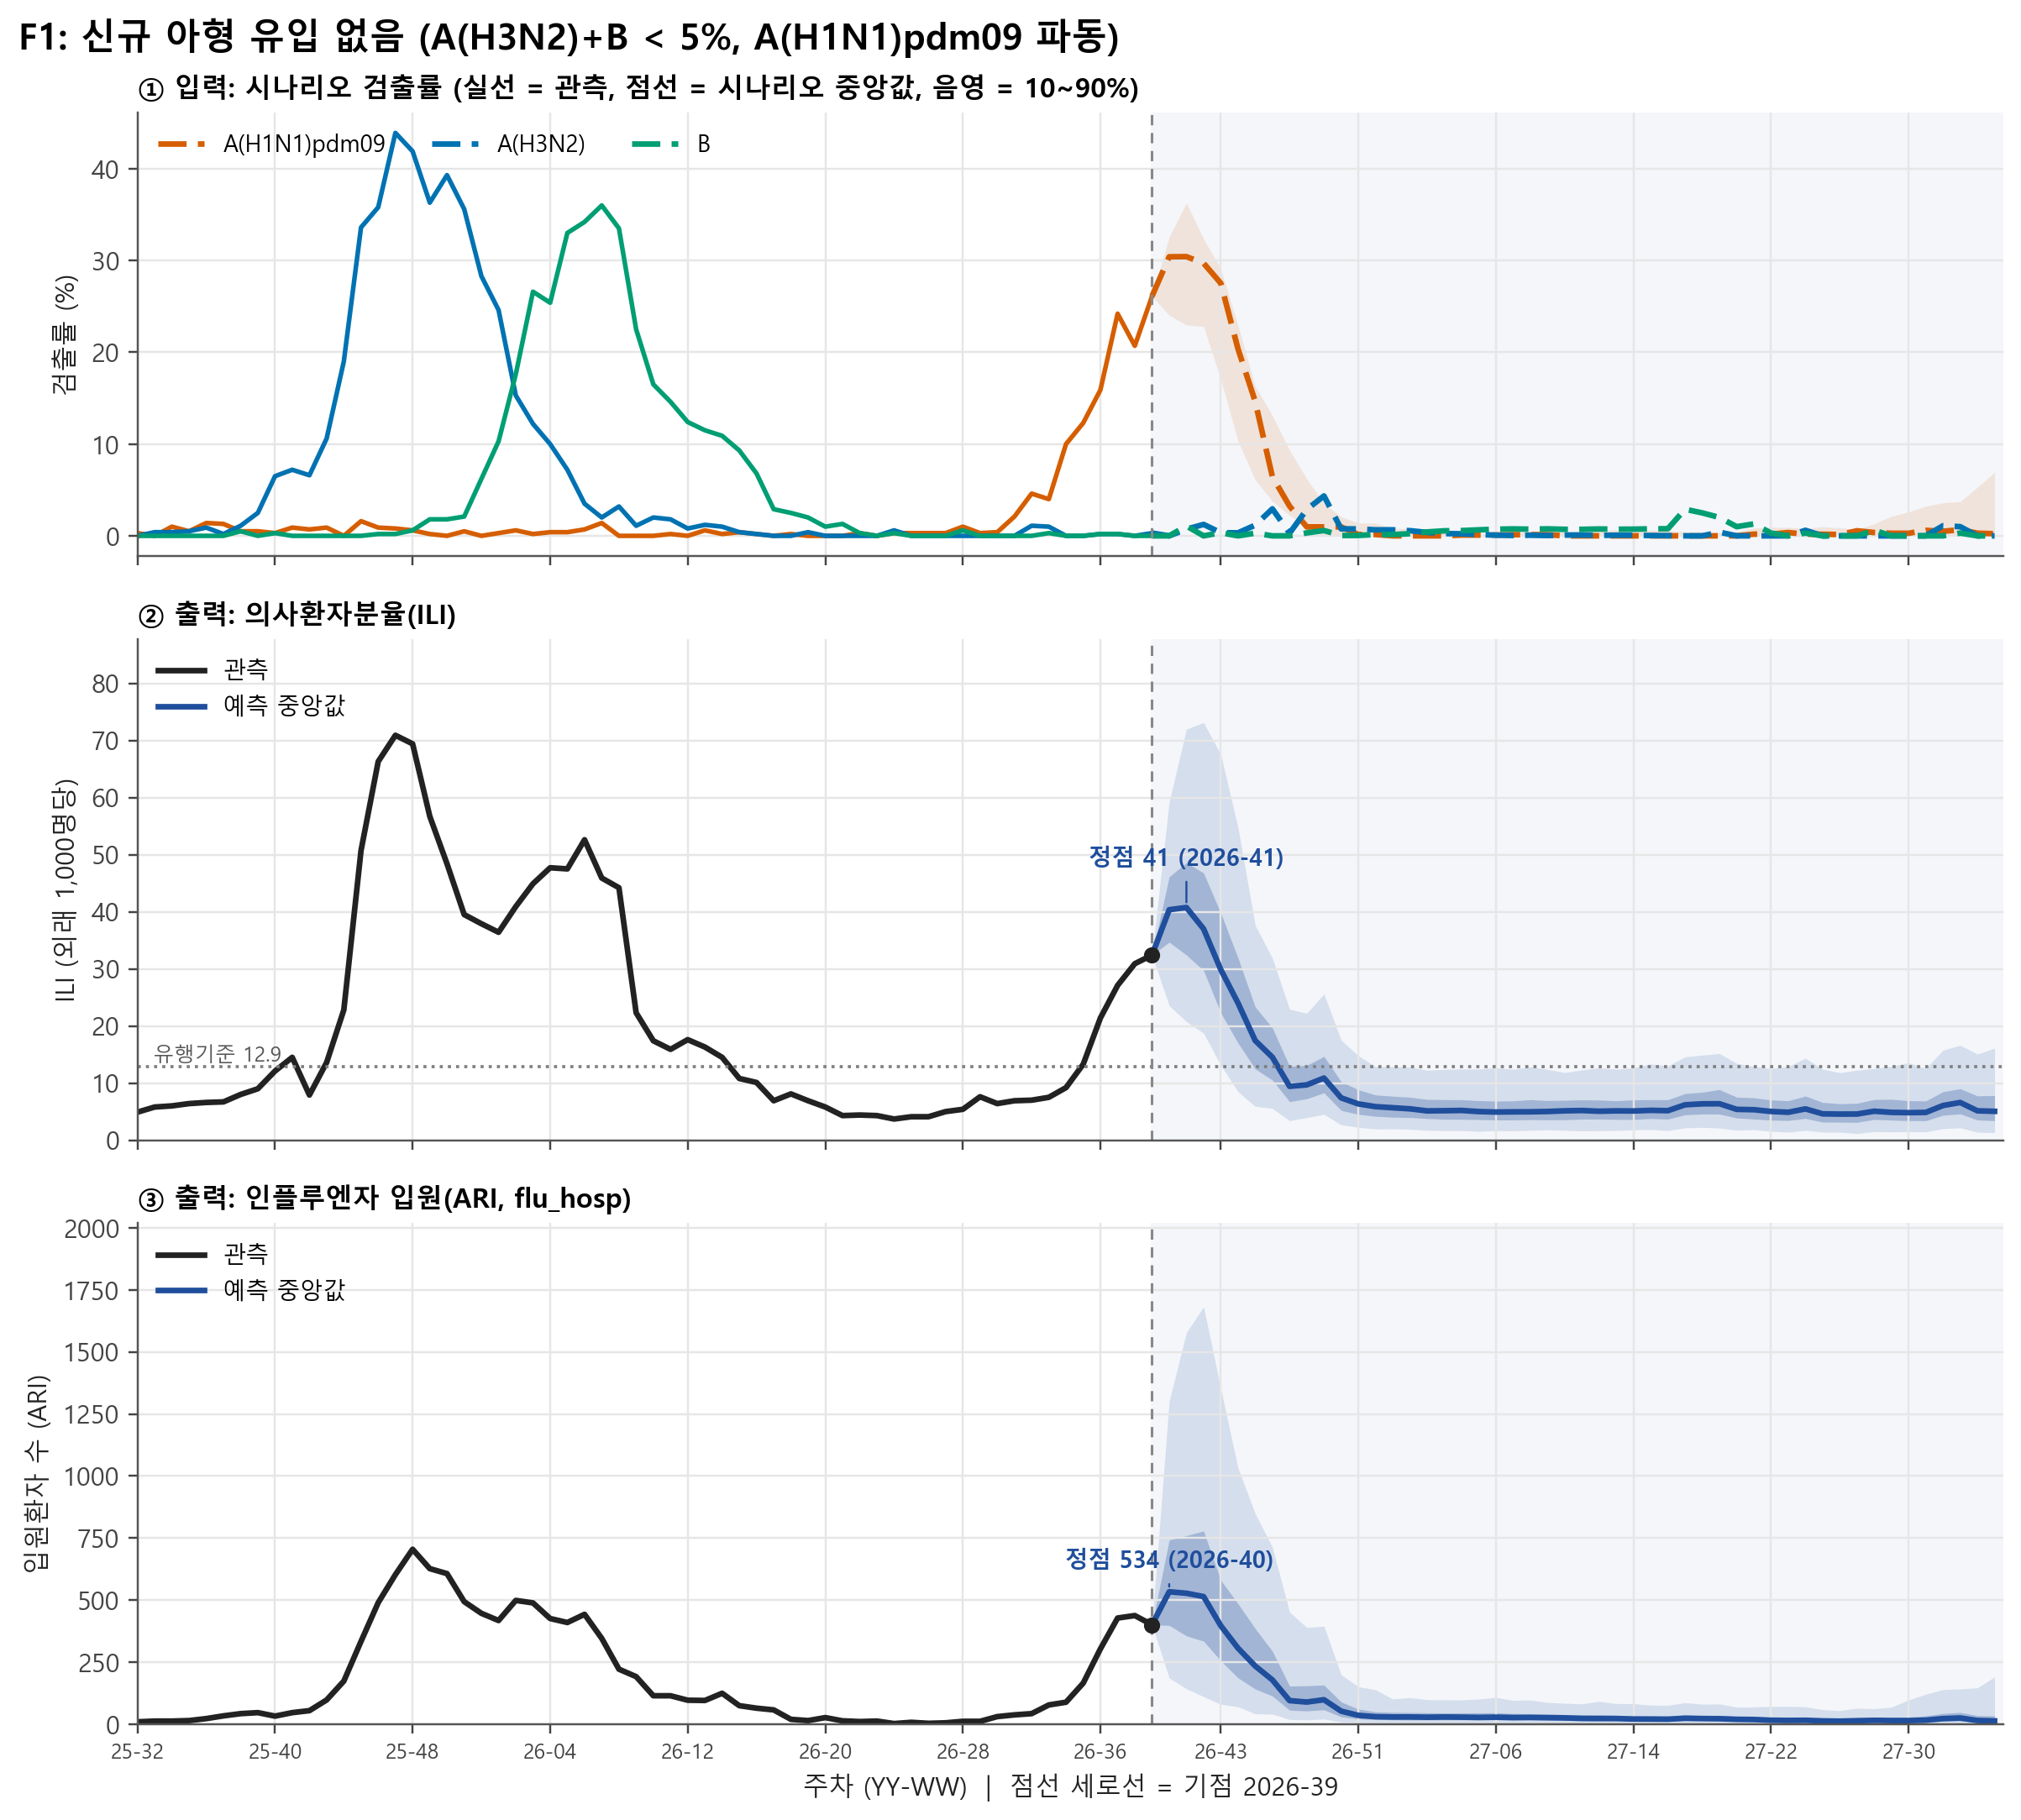

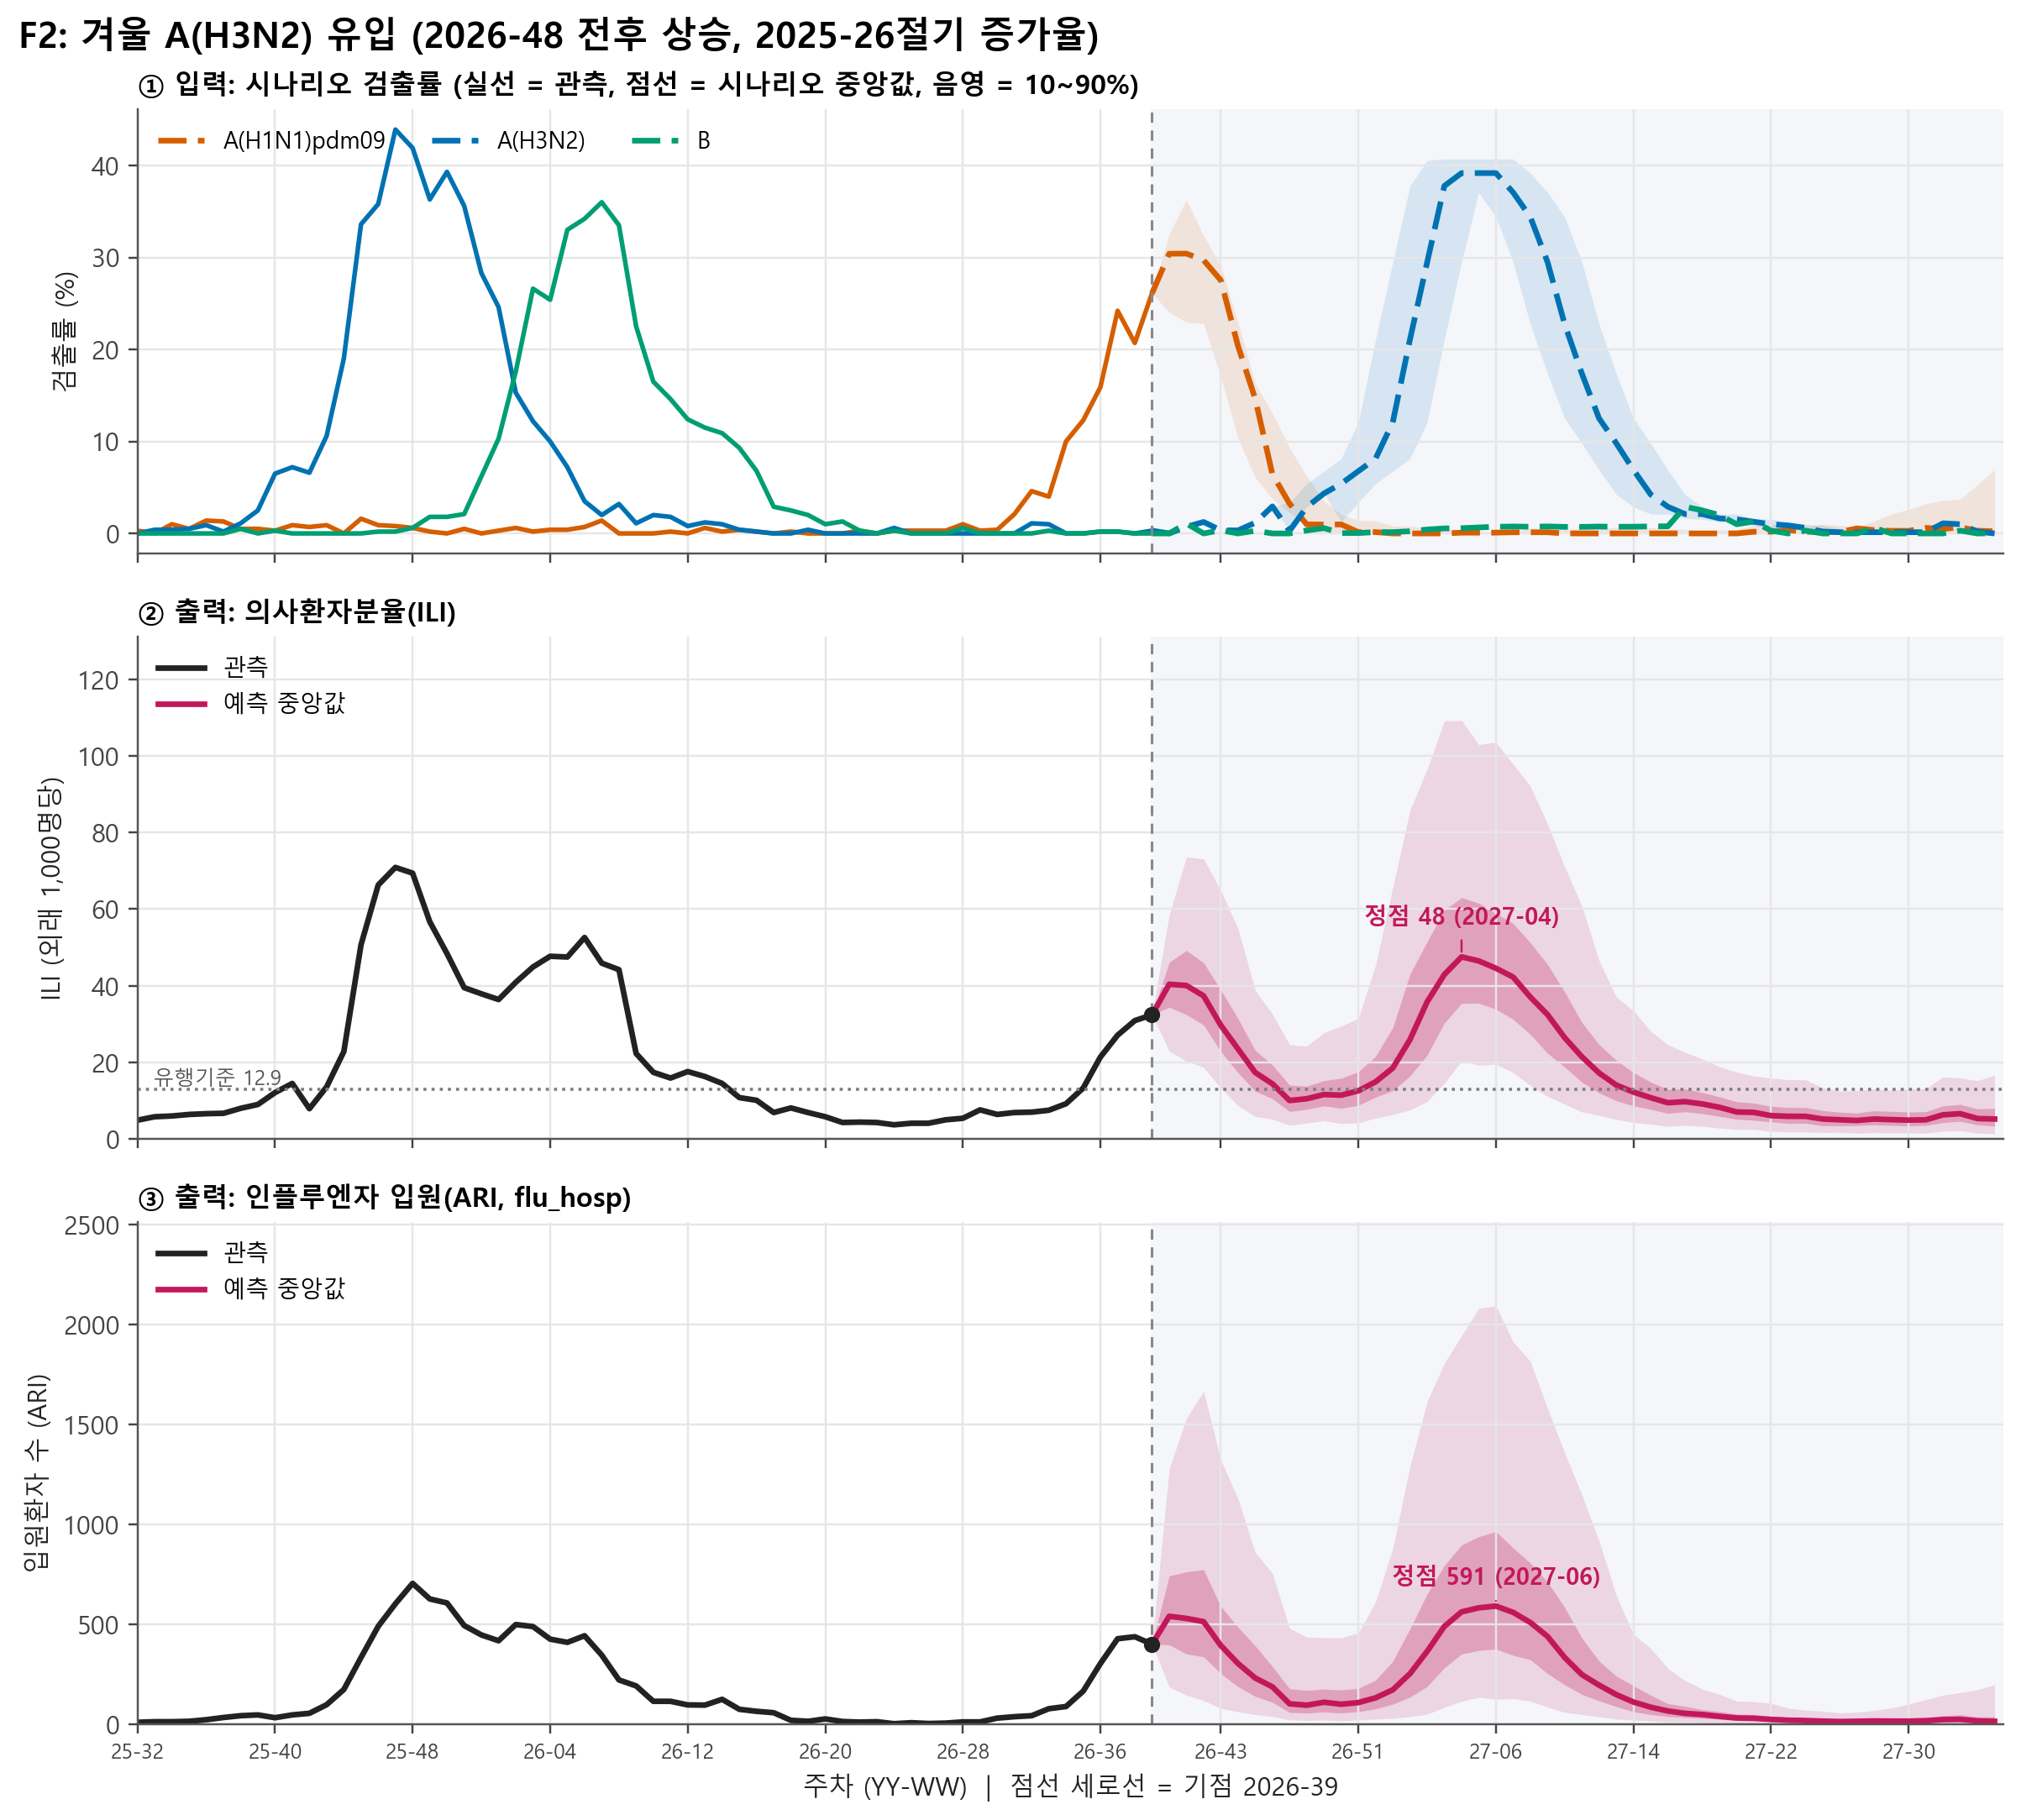

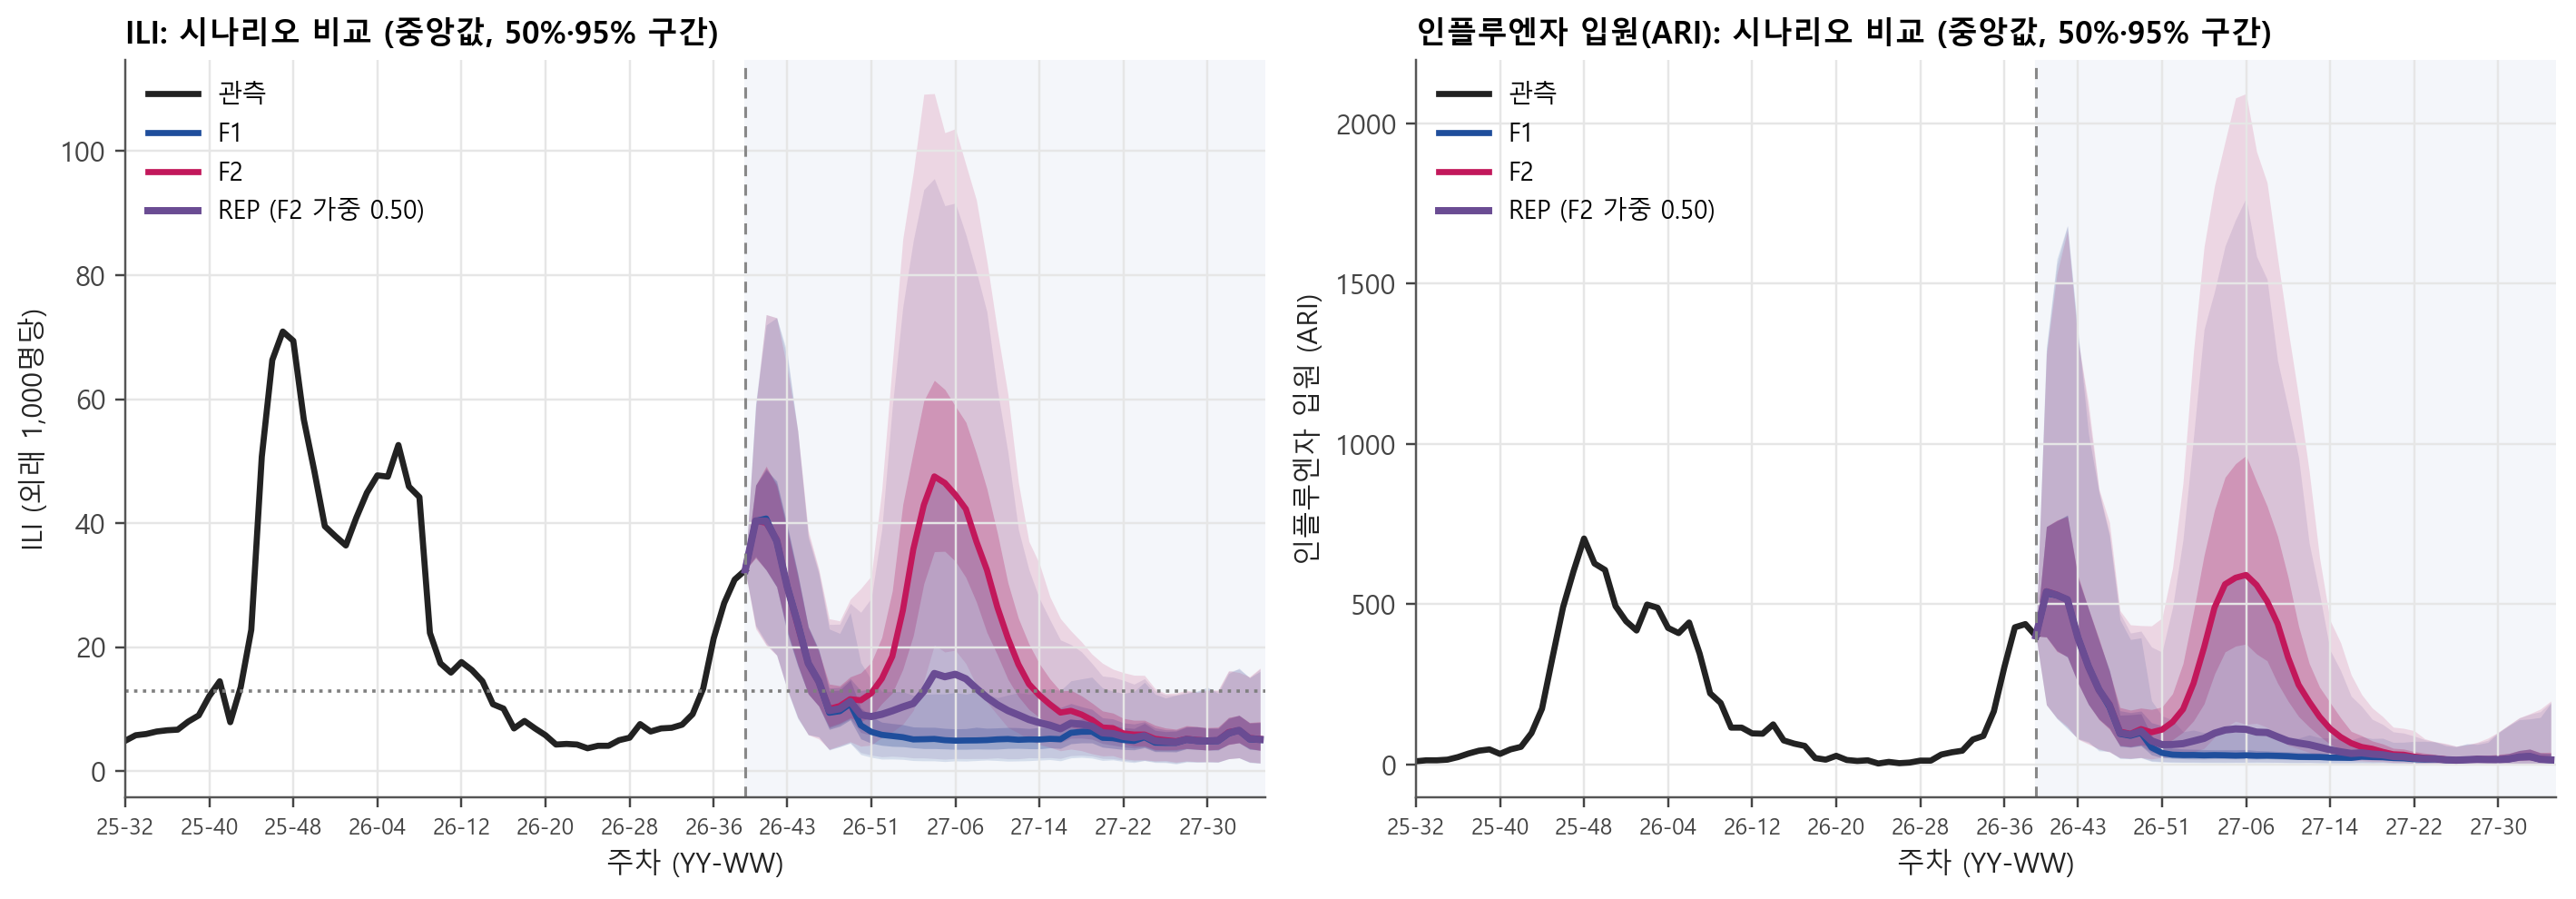

In [6]:
HIST_N = 60
hist = train.iloc[-HIST_N:]
x_hist = np.arange(-HIST_N + 1, 1)
x_fut = np.arange(1, N_STEPS + 1)
hist_labels = [f'{int(v) // 100 % 100}-{int(v) % 100:02d}' for v in hist['년주']]
fut_labels = [f'{s[2:4]}-{s[5:]}' for s in labels]
tick_x = list(range(-HIST_N + 1, 1, 8)) + list(range(4, N_STEPS + 1, 8))
tick_l = [hist_labels[t + HIST_N - 1] if t <= 0 else fut_labels[t - 1] for t in tick_x]


def style_axis(ax, ylabel):
    ax.axvline(0, color='#888888', linewidth=1.0, linestyle=(0, (4, 3)))
    ax.axvspan(0, N_STEPS + 0.5, color='#F4F6FA', zorder=0)
    ax.set_xticks(tick_x, tick_l, rotation=0, fontsize=8)
    ax.set_xlim(-HIST_N + 1, N_STEPS + 0.5)
    ax.set_ylabel(ylabel)


def fan(ax, paths, color, last, label=None, lw=2.2):
    x = np.r_[0, x_fut]
    for lo, hi, a in [(0.025, 0.975, 0.14), (0.25, 0.75, 0.28)]:
        ax.fill_between(x, np.r_[last, np.quantile(paths, lo, axis=0)], np.r_[last, np.quantile(paths, hi, axis=0)], color=color, alpha=a, linewidth=0)
    ax.plot(x, np.r_[last, np.median(paths, axis=0)], color=color, linewidth=lw, label=label)


def scenario_figure(sc, title, path):
    fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True, gridspec_kw={'height_ratios': [1.15, 1.3, 1.3]})
    ax = axes[0]
    d = det_paths[sc]
    for k, (nm, c) in enumerate([('H1', COL['H1']), ('H3', COL['H3']), ('B', COL['B'])], start=1):
        lab = {'H1': 'A(H1N1)pdm09', 'H3': 'A(H3N2)', 'B': 'B'}[nm]
        ax.plot(x_hist, hist[FLU_COLS[k]], color=c, linewidth=1.8)
        ax.plot(np.r_[0, x_fut], np.r_[hist[FLU_COLS[k]].iloc[-1], np.median(d[:, :, k], axis=0)], color=c, linewidth=2.2, linestyle=(0, (5, 2)), label=lab)
        ax.fill_between(np.r_[0, x_fut], np.r_[hist[FLU_COLS[k]].iloc[-1], np.quantile(d[:, :, k], 0.1, axis=0)], np.r_[hist[FLU_COLS[k]].iloc[-1], np.quantile(d[:, :, k], 0.9, axis=0)], color=c, alpha=0.12, linewidth=0)
    ax.set_title('① 입력: 시나리오 검출률 (실선 = 관측, 점선 = 시나리오 중앙값, 음영 = 10~90%)', loc='left', fontsize=10.5, fontweight='bold')
    ax.legend(frameon=False, ncol=3, loc='upper left', fontsize=9)
    style_axis(ax, '검출률 (%)')
    for ax, key, ylab, ttl, thr in [(axes[1], 'ili', 'ILI (외래 1,000명당)', '② 출력: 의사환자분율(ILI)', True), (axes[2], 'flu_hosp', '입원환자 수 (ARI)', '③ 출력: 인플루엔자 입원(ARI, flu_hosp)', False)]:
        col = TARGETS[key]
        ax.plot(x_hist, hist[col], color=COL['obs'], linewidth=2.2, label='관측')
        fan(ax, sim[(key, sc)], COL[sc], hist[col].iloc[-1], label='예측 중앙값')
        ax.scatter([0], [hist[col].iloc[-1]], color=COL['obs'], s=28, zorder=5)
        med = np.median(sim[(key, sc)], axis=0)
        pk = int(np.argmax(med))
        ax.annotate(f'정점 {med[pk]:.0f} ({labels[pk]})', xy=(pk + 1, med[pk]), xytext=(pk + 1, med[pk] * 1.18), ha='center', fontsize=9, color=COL[sc], fontweight='bold', arrowprops=dict(arrowstyle='-', color=COL[sc], lw=0.8))
        if thr:
            ax.axhline(EPI_THRESHOLD, color='#7F7F7F', linestyle=':', linewidth=1.2)
            ax.text(-HIST_N + 1.5, EPI_THRESHOLD, f' 유행기준 {EPI_THRESHOLD}', va='bottom', fontsize=8, color='#555555')
        ax.set_title(ttl, loc='left', fontsize=10.5, fontweight='bold')
        ax.set_ylim(0, max(float(np.quantile(sim[(key, sc)], 0.975, axis=0).max()), float(hist[col].max())) * 1.2)
        style_axis(ax, ylab)
        ax.legend(frameon=False, loc='upper left', fontsize=9)
    axes[2].set_xlabel('주차 (YY-WW)  |  점선 세로선 = 기점 2026-39')
    fig.suptitle(title, x=0.01, ha='left', fontsize=14, fontweight='bold')
    fig.tight_layout()
    fig.savefig(path, bbox_inches='tight')
    plt.close(fig)


scenario_figure('F1', 'F1: 신규 아형 유입 없음 (A(H3N2)+B < 5%, A(H1N1)pdm09 파동)', RESULT_DIR / 'scenario_F1.png')
scenario_figure('F2', 'F2: 겨울 A(H3N2) 유입 (2026-48 전후 상승, 2025-26절기 증가율)', RESULT_DIR / 'scenario_F2.png')
display(Image(filename=str(RESULT_DIR / 'scenario_F1.png')))
display(Image(filename=str(RESULT_DIR / 'scenario_F2.png')))

# 시나리오 비교
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, key, col, ylab in [(axes[0], 'ili', 'ILI', 'ILI (외래 1,000명당)'), (axes[1], 'flu_hosp', 'ARI', '인플루엔자 입원 (ARI)')]:
    ax.plot(x_hist, hist[col], color=COL['obs'], linewidth=2.2, label='관측')
    for sc in ['F1', 'F2', 'REP']:
        fan(ax, sim[(key, sc)], COL[sc], hist[col].iloc[-1], label={'F1': 'F1', 'F2': 'F2', 'REP': f'REP (F2 가중 {W_F2:.2f})'}[sc], lw=2.2 if sc != 'REP' else 2.6)
    if key == 'ili':
        ax.axhline(EPI_THRESHOLD, color='#7F7F7F', linestyle=':', linewidth=1.2)
    style_axis(ax, ylab)
    ax.set_title({'ili': 'ILI', 'flu_hosp': '인플루엔자 입원(ARI)'}[key] + ': 시나리오 비교 (중앙값, 50%·95% 구간)', loc='left', fontweight='bold', fontsize=11)
    ax.legend(frameon=False, loc='upper left', fontsize=9)
    ax.set_xlabel('주차 (YY-WW)')
fig.tight_layout()
fig.savefig(RESULT_DIR / 'scenario_comparison.png', bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(RESULT_DIR / 'scenario_comparison.png')))